<a href="https://colab.research.google.com/github/willchet5-beep/github/blob/master/Simulation_drainage_Bafoussam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simulation de drainage et inondations à Bafoussam**

## Introduction

Ce projet a pour objectif de modéliser le système de drainage urbain de la ville de Bafoussam à l’aide d’un graphe dirigé. L’objectif est de simuler la propagation de l’eau de pluie et d’identifier les zones à risque d’accumulation ou d’inondation. Ce travail s’inscrit dans une démarche de prévention et d’analyse environnementale appliquée à l’urbanisme.



## Objectif du projet

L’étude vise à représenter les caniveaux, rivières et pentes de Bafoussam sous forme d’un graphe orienté afin de comprendre comment l’eau se déplace dans le réseau. À travers cette représentation, il devient possible d’identifier les points où l’eau s’accumule, ce qui permet de mieux anticiper les inondations.



## Méthodologie

Le travail a été réalisé en Python dans Google Colab en suivant une approche progressive.


# Étape 1 : Importation des bibliothèques
Importation des bibliothèques nécessaires :
networkx pour la représentation du graphe.
folium pour la visualisation cartographique.
matplotlib pour d’éventuels tracés de graphes.
pandas pour la manipulation des données.


In [ ]:
# Étape 1 : Préparer l'environnement
!pip install networkx folium pandas matplotlib


# Étape 2 : Création du graphe dirigé
Un graphe orienté a été créé avec networkx.DiGraph().
Chaque nœud représente un élément du réseau hydrologique :
Quartier (ex. Djeleng, Tamdja, Ngouache)
Caniveau ou point de jonction
Rivière Mifi-Sud (exutoire final)
Chaque arc représente le chemin d’écoulement de l’eau entre deux points, orienté selon la pente naturelle du terrain.

In [ ]:
# Étape 2 : Création des données de Bafoussam

import pandas as pd

# Données des noeuds (quartiers, caniveaux, rivière)
noeuds_data = {
    "id": ["N1", "N2", "N3", "N4", "N5", "N6", "N7"],
    "nom": ["Djeleng", "Banengo", "Tamdja", "Ngouache", "Rivière Mifi-Sud (exutoire)",
            "Caniveau principal 1", "Caniveau principal 2"],
    "latitude": [5.4716, 5.4608, 5.4655, 5.4549, 5.4400, 5.4630, 5.4550],
    "longitude": [10.4096, 10.4065, 10.4152, 10.3993, 10.3900, 10.4100, 10.4000],
    "altitude_m": [1420, 1410, 1395, 1370, 1340, 1400, 1380],
    "type": ["quartier", "quartier", "quartier", "quartier", "exutoire", "caniveau", "caniveau"]
}

# Données des arcs (direction de l'eau)
arcs_data = {
    "depart": ["N1", "N1", "N2", "N3", "N6", "N7"],
    "arrivee": ["N3", "N6", "N4", "N7", "N5", "N5"],
    "type": ["caniveau", "caniveau", "caniveau", "caniveau", "rivière", "rivière"]
}

# Création des DataFrames
noeuds = pd.DataFrame(noeuds_data)
arcs = pd.DataFrame(arcs_data)

# Affichage
print("Noeuds (points de drainage) :")
display(noeuds)
print("\nArcs (liaisons entre les points) :")
display(arcs)


Noeuds (points de drainage) :


,id,nom,latitude,longitude,altitude_m,type
0,N1,Djeleng,5.4716,10.4096,1420,quartier
1,N2,Banengo,5.4608,10.4065,1410,quartier
2,N3,Tamdja,5.4655,10.4152,1395,quartier
3,N4,Ngouache,5.4549,10.3993,1370,quartier
4,N5,Rivière Mifi-Sud (exutoire),5.4400,10.3900,1340,exutoire
5,N6,Caniveau principal 1,5.4630,10.4100,1400,caniveau
6,N7,Caniveau principal 2,5.4550,10.4000,1380,caniveau



Arcs (liaisons entre les points) :


,depart,arrivee,type
0,N1,N3,caniveau
1,N1,N6,caniveau
2,N2,N4,caniveau
3,N3,N7,caniveau
4,N6,N5,rivière
5,N7,N5,rivière


# Étape 3 : Données réelles de Bafoussam
Les coordonnées géographiques (latitude, longitude) de quelques points de la ville ont été utilisées pour positionner les nœuds sur la carte.
Les arcs ont été définis selon le sens d’écoulement : de l’amont (quartiers en hauteur) vers l’aval (rivière Mifi).

Nombre de noeuds : 7
Nombre d'arcs : 6


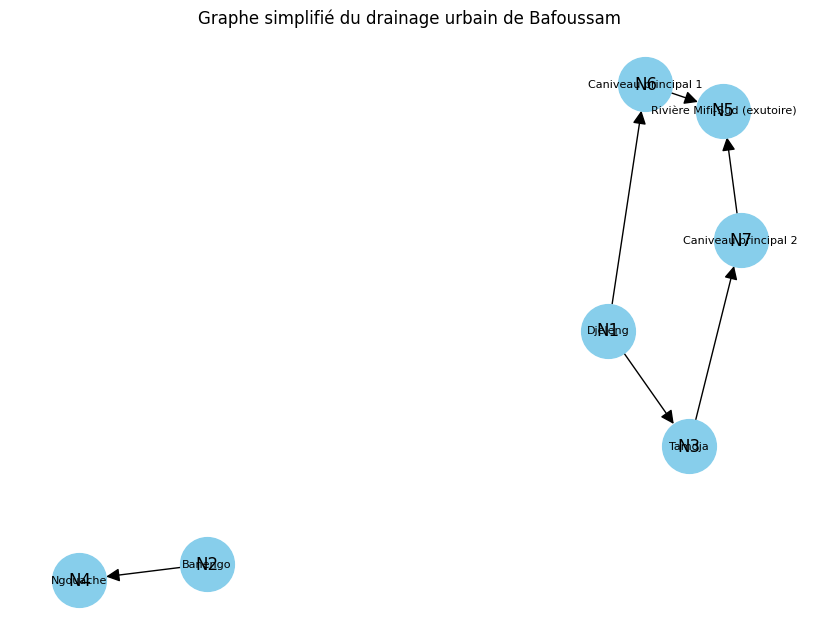

In [ ]:
# Étape 3 : Construction du graphe orienté
import networkx as nx
import matplotlib.pyplot as plt

# Création du graphe orienté
G = nx.DiGraph()

# Ajout des noeuds
for i, row in noeuds.iterrows():
    G.add_node(row["id"], nom=row["nom"], type=row["type"], altitude=row["altitude_m"])

# Ajout des arcs (liaisons orientées)
for i, row in arcs.iterrows():
    G.add_edge(row["depart"], row["arrivee"], type=row["type"])

# Affichage des informations du graphe
print(f"Nombre de noeuds : {G.number_of_nodes()}")
print(f"Nombre d'arcs : {G.number_of_edges()}")

# Visualisation rapide du graphe (sans carte)
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)  # disposition automatique
nx.draw(G, pos, with_labels=True, node_size=1500, node_color="skyblue", arrowsize=20)
nx.draw_networkx_labels(G, pos, {n: G.nodes[n]['nom'] for n in G.nodes}, font_size=8)
plt.title("Graphe simplifié du drainage urbain de Bafoussam")
plt.show()


# Étape 4 : Simulation du drainage (parcours BFS et DFS)
Deux algorithmes d’exploration ont été implémentés :
BFS (Breadth-First Search) : pour simuler une propagation en largeur, comme une montée d’eau rapide.
DFS (Depth-First Search) : pour simuler un écoulement en profondeur, suivant un trajet unique jusqu’à l’exutoire.
Ces algorithmes permettent de visualiser le chemin de l’eau depuis un point donné jusqu’à la rivière.

In [ ]:
# Étape 4 : Visualisation du graphe sur une carte réelle
import folium

# Création de la carte centrée sur Bafoussam
centre_lat, centre_lon = 5.465, 10.405
carte = folium.Map(location=[centre_lat, centre_lon], zoom_start=13, tiles="CartoDB positron")

# Ajout des noeuds (quartiers, caniveaux, rivière)
for i, row in noeuds.iterrows():
    couleur = "blue" if row["type"] == "quartier" else "green" if row["type"] == "caniveau" else "red"
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=7,
        color=couleur,
        fill=True,
        fill_opacity=0.8,
        popup=f"{row['nom']} ({row['type']}) - {row['altitude_m']} m"
    ).add_to(carte)

# Ajout des arcs (direction de l'eau)
for i, row in arcs.iterrows():
    start = noeuds.loc[noeuds["id"] == row["depart"]].iloc[0]
    end = noeuds.loc[noeuds["id"] == row["arrivee"]].iloc[0]
    folium.PolyLine(
        locations=[[start["latitude"], start["longitude"]], [end["latitude"], end["longitude"]]],
        color="blue",
        weight=3,
        opacity=0.7,
        tooltip=f"De {start['nom']} vers {end['nom']} ({row['type']})"
    ).add_to(carte)

# Affichage de la carte
carte


# Étape 5 : Visualisation du réseau
Une carte interactive Folium a été créée pour visualiser :
Les points du réseau (quartiers, caniveaux, rivière).
Les arcs représentant les canalisations ou pentes.
Chaque nœud est cliquable pour afficher son nom et son type.

In [ ]:
# Étape 5 : Simulation du parcours de l'eau (BFS et DFS)
from collections import deque

def bfs(G, start):
    """Parcours en largeur (Breadth-First Search)"""
    visited = []
    queue = deque([start])
    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.append(node)
            neighbors = list(G.neighbors(node))
            queue.extend(neighbors)
    return visited

def dfs(G, start, visited=None):
    """Parcours en profondeur (Depth-First Search)"""
    if visited is None:
        visited = []
    visited.append(start)
    for neighbor in G.neighbors(start):
        if neighbor not in visited:
            dfs(G, neighbor, visited)
    return visited

# Test : depuis le quartier Djeleng (N1)
depart = "N1"
print("Simulation depuis :", G.nodes[depart]["nom"])

parcours_bfs = bfs(G, depart)
parcours_dfs = dfs(G, depart)

# Affichage des résultats
print("\nOrdre de visite (BFS) :")
for n in parcours_bfs:
    print(" →", G.nodes[n]["nom"])

print("\nOrdre de visite (DFS) :")
for n in parcours_dfs:
    print(" →", G.nodes[n]["nom"])


Simulation depuis : Djeleng

Ordre de visite (BFS) :
 → Djeleng
 → Tamdja
 → Caniveau principal 1
 → Caniveau principal 2
 → Rivière Mifi-Sud (exutoire)

Ordre de visite (DFS) :
 → Djeleng
 → Tamdja
 → Caniveau principal 2
 → Rivière Mifi-Sud (exutoire)
 → Caniveau principal 1


# Étape 6 : Détection des zones d’accumulation
Pour chaque nœud, on calcule :
Le nombre d’entrées (in_degree) → indique combien de flux d’eau arrivent.
Le nombre de sorties (out_degree) → indique combien de directions l’eau peut emprunter.
Une zone est considérée comme à risque si :
Elle reçoit plusieurs arrivées d’eau (in_degree > 1), ou
Elle n’a aucune sortie (out_degree == 0).
Ces zones correspondent souvent à des points bas ou caniveaux surchargés.

In [ ]:
# Étape 6 : Identifier les zones d'accumulation d'eau

# Calcul des degrés entrants et sortants
for node in G.nodes:
    G.nodes[node]['in_degree'] = G.in_degree(node)
    G.nodes[node]['out_degree'] = G.out_degree(node)

# Recherche des zones problématiques
zones_accumulation = []
for node in G.nodes:
    entree = G.nodes[node]['in_degree']
    sortie = G.nodes[node]['out_degree']

    if entree > 1 or sortie == 0:  # plusieurs arrivées ou aucune sortie
        zones_accumulation.append((G.nodes[node]['nom'], entree, sortie))

# Affichage
print("🌧️ Zones potentielles d'accumulation d'eau :\n")
if zones_accumulation:
    for nom, entree, sortie in zones_accumulation:
        print(f"- {nom} (entrées: {entree}, sorties: {sortie})")
else:
    print("Aucune zone d'accumulation détectée dans ce modèle.")


🌧️ Zones potentielles d'accumulation d'eau :

- Ngouache (entrées: 1, sorties: 0)
- Rivière Mifi-Sud (exutoire) (entrées: 2, sorties: 0)


# Étape 7 : Visualisation des zones à risque
Les zones identifiées à risque sont représentées :
En rouge sur la carte (risque d’inondation ou accumulation).
Les zones normales sont en bleu.
Les caniveaux en vert.
Cette visualisation permet de repérer rapidement les zones critiques du réseau de drainage urbain.

In [ ]:
# Étape 7 : Visualisation des zones d'accumulation sur la carte

# Recréation d'une carte
carte_risque = folium.Map(location=[5.465, 10.405], zoom_start=13, tiles="CartoDB positron")

# Ajout des noeuds avec codes couleur selon le risque
for i, row in noeuds.iterrows():
    # Vérifie si ce nœud est une zone d'accumulation
    est_risque = any(row["nom"] in z[0] for z in zones_accumulation)
    couleur = "red" if est_risque else ("blue" if row["type"] == "quartier" else "green")

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=8,
        color=couleur,
        fill=True,
        fill_opacity=0.9,
        popup=f"{row['nom']} ({row['type']})"
    ).add_to(carte_risque)

# Ajout des arcs du réseau
for i, row in arcs.iterrows():
    start = noeuds.loc[noeuds["id"] == row["depart"]].iloc[0]
    end = noeuds.loc[noeuds["id"] == row["arrivee"]].iloc[0]
    folium.PolyLine(
        locations=[[start["latitude"], start["longitude"]], [end["latitude"], end["longitude"]]],
        color="blue",
        weight=3,
        opacity=0.6
    ).add_to(carte_risque)

# Affichage de la carte finale
carte_risque


## Résultats et interprétation

L’analyse met en évidence que :

* Les zones situées en aval, proches de la rivière Mifi, sont les plus vulnérables aux accumulations.
* Certains caniveaux intermédiaires reçoivent l’eau de plusieurs quartiers, augmentant le risque de débordement en cas de fortes pluies.
* Le centre-ville et les quartiers bas (Ngouache, Tougang) sont des points sensibles.



## Conclusion

Cette simulation montre qu’un modèle basé sur les graphes permet de :

* Représenter simplement le réseau de drainage urbain.
* Identifier les zones d’accumulation d’eau à partir de relations topologiques.
* Aider à la planification urbaine pour réduire les risques d’inondation.

Des améliorations possibles incluent :

* L’intégration de données topographiques réelles (pentes).
* La simulation dynamique du débit d’eau selon la pluie.
* L’ajout de capteurs pour la détection en temps réel.


**Membres du groupe  :**

*   CHETEU FODJO WILLIAM
*   KENMOGNE SERGINHO RANDOLF
*   TAMO FOTSO ULRICHE SOREL





**Projet :** Simulation du drainage urbain de Bafoussam

